# Exploratory Data Analysis 

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.data_fetching.load_data import load_processed_data

sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [2]:
train_df, _ = load_processed_data()

target = 'SeriousDlqin2yrs'
feature_cols = [c for c in train_df.columns if c not in ['Id', target]]

print(f"Shape: {train_df.shape}")
train_df[feature_cols + [target]].head()


Loading training data from: /home/ysrrezk/CreditRisk-ML/data/processed/processed_train.csv
Loading testing data from: /home/ysrrezk/CreditRisk-ML/data/processed/processed_test.csv
Data loaded successfully!

Shape: (145698, 13)


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyDebt,NonRealEstateLoans,SeriousDlqin2yrs
0,0.77,45.00,2,"9,120.00",13.00,0,6.00,0,2.00,"7,323.20",7.00,1
1,0.96,40.00,0,"2,600.00",4.00,0,0.00,0,1.00,316.88,4.00,0
2,0.66,38.00,1,"3,042.00",2.00,1,0.00,0,0.00,258.91,2.00,0
3,0.23,30.00,0,"3,300.00",5.00,0,0.00,0,0.00,118.96,5.00,0
4,0.91,49.00,1,"63,588.00",7.00,0,1.00,0,0.00,"1,584.98",6.00,0


## 1. Descriptive Statistics

Central tendency (mean, median) and dispersion (std, IQR) for every feature. Where mean and
median diverge a lot, that's a sign of skew — worth flagging before we trust the mean alone.

In [3]:
desc = train_df[feature_cols].describe().T
desc['median'] = train_df[feature_cols].median()
desc['skew'] = train_df[feature_cols].skew()
desc = desc[['mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'skew']]
desc


,mean,median,std,min,25%,50%,75%,max,skew
RevolvingUtilizationOfUnsecuredLines,0.30,0.14,0.34,0.00,0.03,0.14,0.51,1.00,0.97
age,52.51,52.00,14.69,21.00,42.00,52.00,63.00,109.00,0.19
NumberOfTime30-59DaysPastDueNotWorse,0.23,0.00,0.67,0.00,0.00,0.00,0.00,13.00,4.38
MonthlyIncome,"6,637.21","5,416.00","13,438.92",0.00,"3,818.00","5,416.00","7,983.06","3,008,750.00",117.32
NumberOfOpenCreditLinesAndLoans,8.55,8.00,5.14,0.00,5.00,8.00,11.00,58.00,1.22
NumberOfTimes90DaysLate,0.08,0.00,0.44,0.00,0.00,0.00,0.00,17.00,9.88
NumberRealEstateLoansOrLines,1.03,1.00,1.13,0.00,0.00,1.00,2.00,54.00,3.51
NumberOfTime60-89DaysPastDueNotWorse,0.06,0.00,0.30,0.00,0.00,0.00,0.00,11.00,8.03
NumberOfDependents,0.75,0.00,1.11,0.00,0.00,0.00,1.00,20.00,1.61
MonthlyDebt,"2,063.50","1,567.51","4,212.16",0.00,550.89,"1,567.51","2,814.43","478,450.56",54.28


In [4]:
# Flag the features where mean and median disagree the most (skew indicator)
skew_ranked = desc['skew'].abs().sort_values(ascending=False)
print("Features ranked by skew (most skewed first):")
skew_ranked


Features ranked by skew (most skewed first):


MonthlyIncome                          117.32
MonthlyDebt                             54.28
NumberOfTimes90DaysLate                  9.88
NumberOfTime60-89DaysPastDueNotWorse     8.03
NumberOfTime30-59DaysPastDueNotWorse     4.38
NumberRealEstateLoansOrLines             3.51
NumberOfDependents                       1.61
NonRealEstateLoans                       1.36
NumberOfOpenCreditLinesAndLoans          1.22
RevolvingUtilizationOfUnsecuredLines     0.97
age                                      0.19
Name: skew, dtype: float64

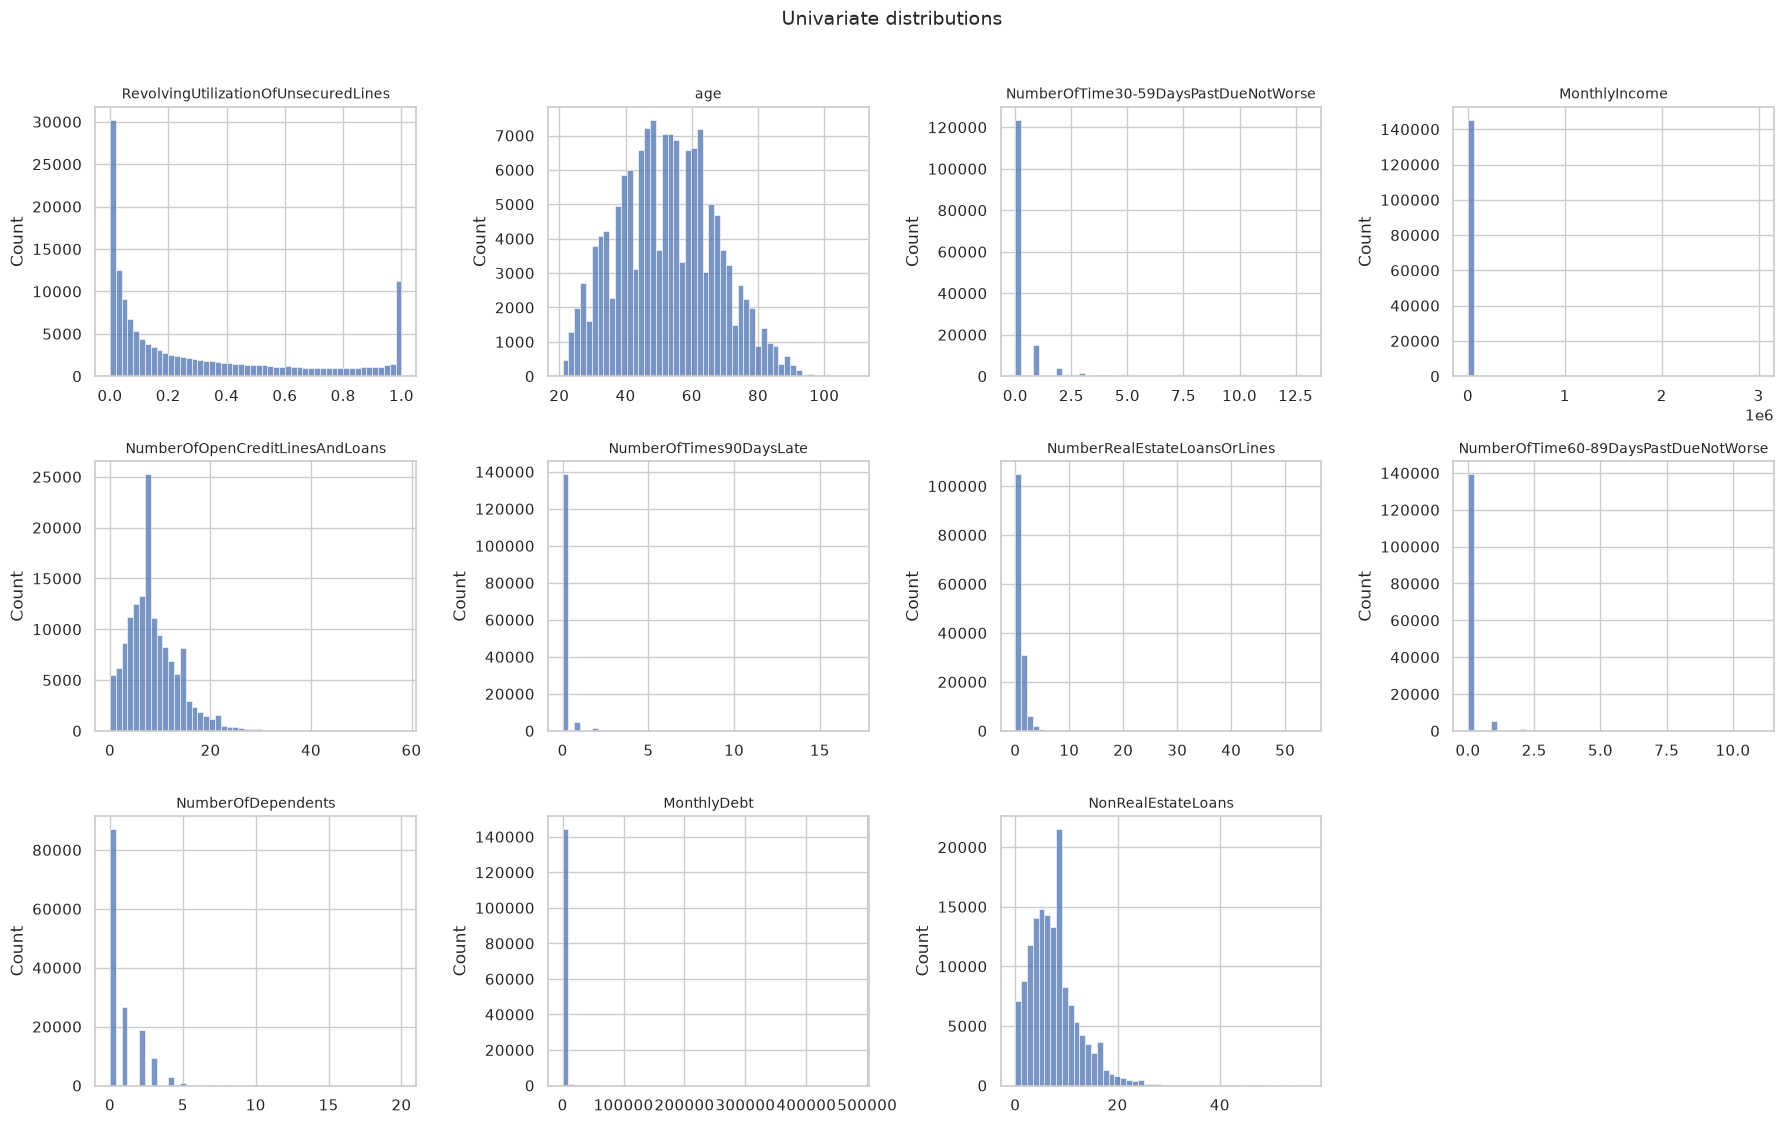

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.histplot(train_df[col], bins=50, ax=axes[i], kde=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Univariate distributions', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 2. Target Distribution

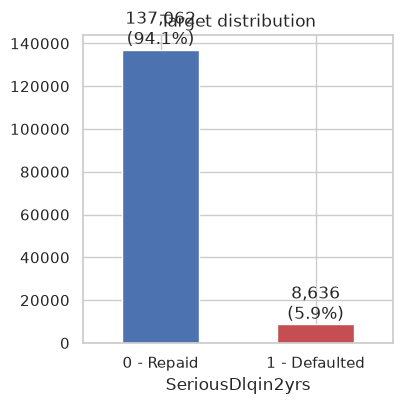

In [6]:
target_counts = train_df[target].value_counts()
target_pct = train_df[target].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(4, 4))
target_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_xticklabels(['0 - Repaid', '1 - Defaulted'], rotation=0)
ax.set_title('Target distribution')
for i, v in enumerate(target_counts):
    ax.text(i, v, f"{v:,}\n({target_pct.iloc[i]:.1f}%)", ha='center', va='bottom')
plt.show()


## 3. Correlations and Relationships

### 3.1 Feature-to-feature and feature-to-target correlation

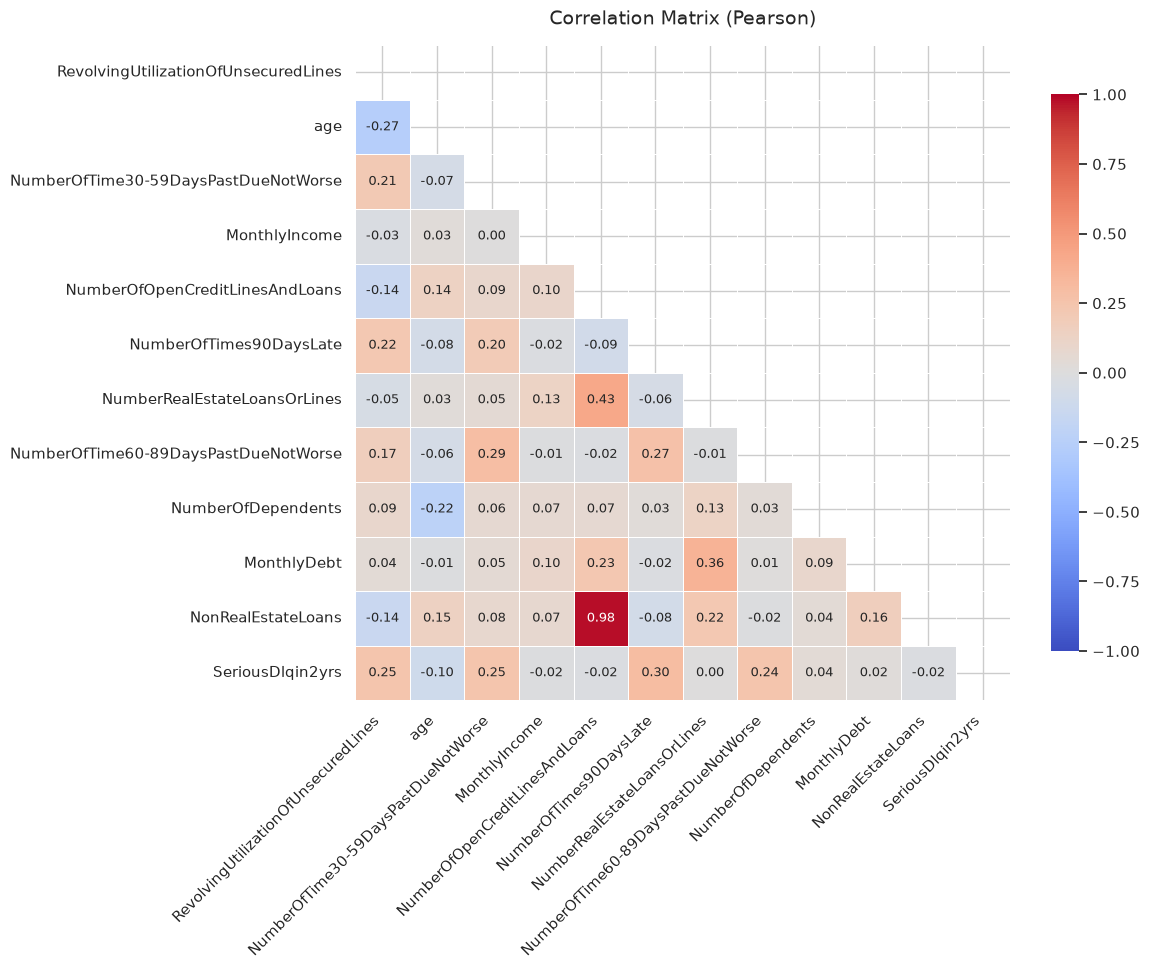

In [ ]:
corr = train_df[feature_cols + [target]].corr()

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9},
)

plt.title("Correlation Matrix (Pearson)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
target_corr = corr[target].drop(target).sort_values(key=np.abs, ascending=False)
print("Features ranked by |correlation| with the target:")
target_corr


Features ranked by |correlation| with the target:


NumberOfTimes90DaysLate                 0.30
NumberOfTime30-59DaysPastDueNotWorse    0.25
RevolvingUtilizationOfUnsecuredLines    0.25
NumberOfTime60-89DaysPastDueNotWorse    0.24
age                                    -0.10
NumberOfDependents                      0.04
MonthlyDebt                             0.02
NonRealEstateLoans                     -0.02
NumberOfOpenCreditLinesAndLoans        -0.02
MonthlyIncome                          -0.02
NumberRealEstateLoansOrLines            0.00
Name: SeriousDlqin2yrs, dtype: float64

In [ ]:
# Multicollinearity check: which feature pairs are most correlated with EACH OTHER
corr_features_only = train_df[feature_cols].corr().abs()
upper = corr_features_only.where(np.triu(np.ones(corr_features_only.shape), k=1).astype(bool))
pairs = upper.stack().sort_values(ascending=False)
print("Most correlated feature PAIRS (excluding the target):")
pairs.head(10)


Most correlated feature PAIRS (excluding the target):


NumberOfOpenCreditLinesAndLoans       NonRealEstateLoans                     0.98
                                      NumberRealEstateLoansOrLines           0.43
NumberRealEstateLoansOrLines          MonthlyDebt                            0.36
NumberOfTime30-59DaysPastDueNotWorse  NumberOfTime60-89DaysPastDueNotWorse   0.29
NumberOfTimes90DaysLate               NumberOfTime60-89DaysPastDueNotWorse   0.27
RevolvingUtilizationOfUnsecuredLines  age                                    0.27
NumberOfOpenCreditLinesAndLoans       MonthlyDebt                            0.23
NumberRealEstateLoansOrLines          NonRealEstateLoans                     0.22
age                                   NumberOfDependents                     0.22
RevolvingUtilizationOfUnsecuredLines  NumberOfTimes90DaysLate                0.22
dtype: float64

### 3.2 How key features differ between defaulters and non-defaulters


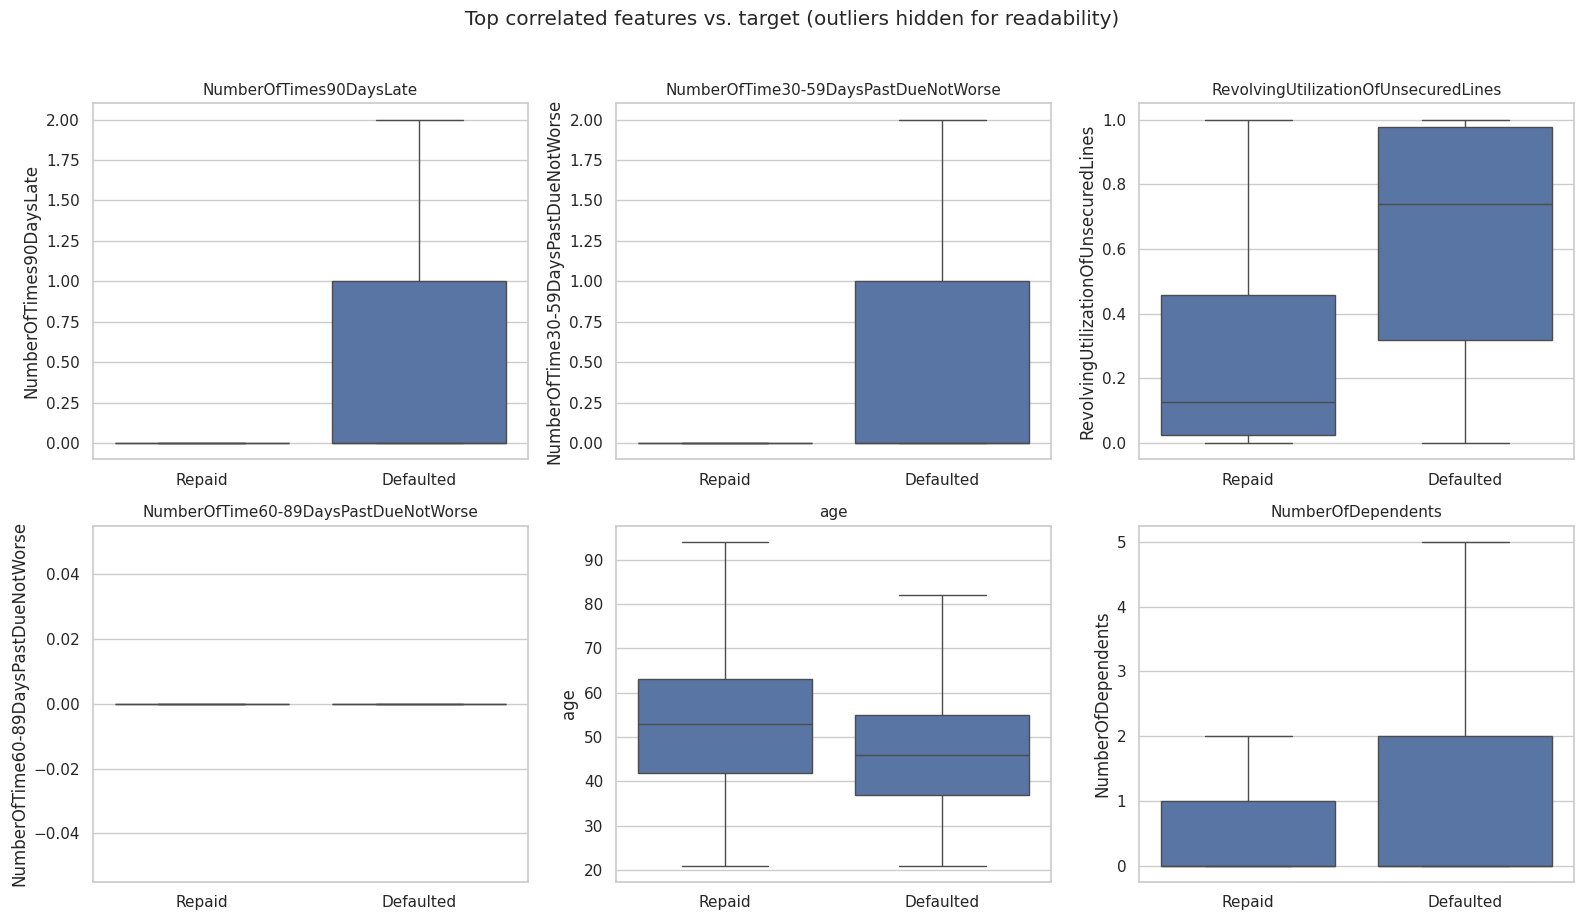

In [10]:
top_features = target_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(top_features):
    sns.boxplot(data=train_df, x=target, y=col, ax=axes[i], showfliers=False)
    axes[i].set_xticklabels(['Repaid', 'Defaulted'])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
plt.suptitle('Top correlated features vs. target (outliers hidden for readability)', y=1.02)
plt.tight_layout()
plt.show()


In [11]:
# Same comparison as a table: mean of each top feature, split by target
train_df.groupby(target)[top_features].mean().T.rename(
    columns={0: 'Mean (Repaid)', 1: 'Mean (Defaulted)'}
)


SeriousDlqin2yrs,Mean (Repaid),Mean (Defaulted)
NumberOfTimes90DaysLate,0.05,0.60
NumberOfTime30-59DaysPastDueNotWorse,0.19,0.89
RevolvingUtilizationOfUnsecuredLines,0.28,0.63
NumberOfTime60-89DaysPastDueNotWorse,0.04,0.35
age,52.89,46.46
NumberOfDependents,0.73,0.94


**Key insight:** across every one of the top features, the "Defaulted" group has a visibly
higher median/mean than the "Repaid" group — consistent with the correlation direction above.
The separation isn't dramatic for any single feature (there's real overlap between the two
groups), which again explains why the best models here reach ROC-AUC around 0.86 rather than
something closer to 1.0: no individual feature cleanly separates the two classes, so the model
has to combine several weak signals.

### 3.3 A non-linear relationship worth calling out: `age`

`age` had a weak linear correlation with the target above. That doesn't mean age is
unimportant — it may have a **non-linear** relationship (e.g. risk is elevated for young
borrowers, drops in middle age, and behaves differently for retirees), which a Pearson
correlation coefficient can't detect.

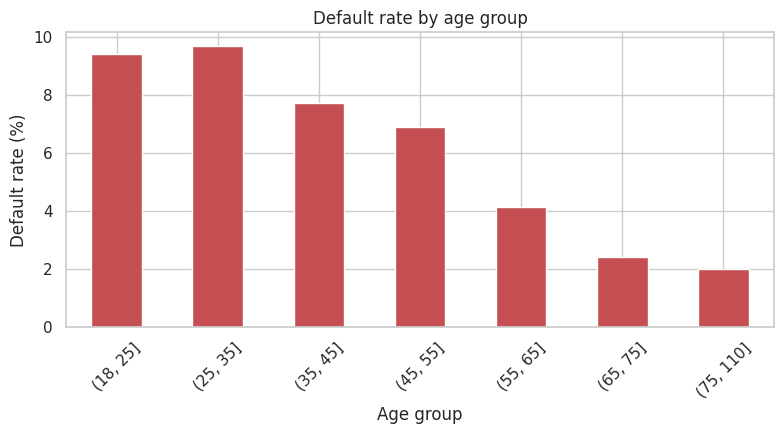

In [12]:
age_bins = pd.cut(train_df['age'], bins=[18, 25, 35, 45, 55, 65, 75, 110])
default_rate_by_age = train_df.groupby(age_bins, observed=True)[target].mean() * 100

plt.figure(figsize=(8, 4.5))
default_rate_by_age.plot(kind='bar', color='#C44E52')
plt.ylabel('Default rate (%)')
plt.xlabel('Age group')
plt.title('Default rate by age group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Key insight:** default rate is highest for the youngest age group and steadily decreases
with age. This is a real, meaningful pattern that a linear correlation coefficient understated —
a good example of why both correlation analysis AND grouped/bucketed analysis are useful
together, not one instead of the other.

## 4. Summary of Key Findings

- **Class imbalance**: ~6% of borrowers defaulted. Requires imbalance-aware modeling and
  ROC-AUC (not accuracy) as the evaluation metric.
- **Skewed features**: utilization, income, and delinquency-count columns are heavily
  right-skewed — a small number of extreme values drive the mean well above the median.
- **No single strong predictor**: every feature has weak-to-moderate correlation with the
  target individually. The delinquency-history counts and revolving utilization are the
  strongest, but none exceed ~0.3 in absolute correlation — supports using models that can
  combine multiple weak signals (tree ensembles) over a single-rule approach.
- **Multicollinearity**: a few feature pairs are meaningfully correlated with each other,
  worth keeping in mind if a future iteration of this project uses Logistic Regression as the
  primary model rather than a baseline.
- **Non-linear effects exist**: `age` shows a monotonic decline in default rate that a linear
  correlation coefficient alone doesn't fully capture — reinforces the case for non-linear
  models over linear ones for this problem.
